# Kidney lncRNA Pipeline

### Setting up environment

In [1]:
# libraries
import sys
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "notebook"
import nsforest as ns
from nsforest import utils
import celltypist as ct

/opt/miniconda3/envs/nsforest/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
# configs
code_folder = "/Users/vbecker/Desktop/NSForest-ncRNA"
sys.path.insert(0, os.path.abspath(code_folder))

data_folder = "../beckersv_data/"
file = data_folder + "nsf_kidney.h5ad"

output_folder = "../beckersv_output_kidney/"

to_downsample = True
to_downsample_num = 100000

seed = 1990

### Data Exploration

#### Loading AnnData file

In [3]:
adata_raw = sc.read_h5ad(file)
adata_raw

AnnData object with n_obs × n_vars = 304652 × 33140
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicit

#### Looking at sample labels

In [4]:
adata_raw.obs_names # sample names

Index(['KB1_AAACCCAAGCCGATAG', 'KB1_AAACCCAAGGAACTAT', 'KB1_AAACCCAAGGTTATAG',
       'KB1_AAACCCAGTAATGCGG', 'KB1_AAACCCAGTACTAACC', 'KB1_AAACCCAGTGCGAACA',
       'KB1_AAACCCAGTTGTGCAT', 'KB1_AAACCCATCAGGTGTT', 'KB1_AAACCCATCTTAAGGC',
       'KB1_AAACGAAAGAGTCAAT',
       ...
       'LDSample1162EO2_TTTGACTGTATCGTGT-1',
       'LDSample1162EO2_TTTGACTGTCGCCACA-1',
       'LDSample1162EO2_TTTGATCAGTTGCCTA-1',
       'LDSample1162EO2_TTTGATCGTGAGTAGC-1',
       'LDSample1162EO2_TTTGATCGTGTGGTCC-1',
       'LDSample1162EO2_TTTGATCTCTCCTGCA-1',
       'LDSample1162EO2_TTTGGAGAGCAGGCAT-1',
       'LDSample1162EO2_TTTGGAGAGTGCTCGC-1',
       'LDSample1162EO2_TTTGGAGGTGATACTC-1',
       'LDSample1162EO2_TTTGGTTCAGTAGAAT-1'],
      dtype='object', name='index', length=304652)

In [5]:
adata_raw.obs.columns # sample metadata

Index(['nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt',
       'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score',
       'matrisome.score', 'collagen.score', 'glycoprotein.score',
       'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen',
       'condition.long', 'condition.l1', 'condition.l2', 'donor_id',
       'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla',
       'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed',
       'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1',
       'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id',
       'sex_ontology_term_id', 'development_stage_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI',
       'diabetes_history', 'hypertension', 'tissue_ontology_term_id',
       'assay_ontology_term_id', 'cell_type_ontology_term_id',
       'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type',
       'assay', 'diseas

#### Looking at genes

**Note:** `adata.var_names` must be unique. If there is a problem, usually it can be solved by assigning `adata.var.index = adata.var["ensembl_id"]`. 

In [6]:
adata_raw.var_names # gene names

Index(['ENSG00000121410', 'ENSG00000268895', 'ENSG00000148584',
       'ENSG00000175899', 'ENSG00000245105', 'ENSG00000166535',
       'ENSG00000256661', 'ENSG00000184389', 'ENSG00000128274',
       'ENSG00000118017',
       ...
       'ENSG00000207468', 'ENSG00000201821', 'ENSG00000199477',
       'ENSG00000222489', 'ENSG00000242737', 'ENSG00000279622',
       'ENSG00000261499', 'ENSG00000279570', 'ENSG00000249263',
       'ENSG00000253460'],
      dtype='object', length=33140)

In [7]:
adata_raw.var.columns # gene metadata
adata_raw.var["feature_type"].value_counts().head(5)

feature_type
protein_coding                        18722
lncRNA                                11509
processed_pseudogene                   1084
transcribed_unprocessed_pseudogene      532
TEC                                     430
Name: count, dtype: int64

### Downsampling and Subsetting

#### Defining `cluster_header` as cell type annotation and gene comparison for subset.

**Note:** Some datasets have multiple annotations per sample (ex. "broad_cell_type" and "granular_cell_type"). NS-Forest can be run on multiple `cluster_header`'s. Combining the parent and child markers may improve classification results. 

In [8]:
cluster_header = "cell_type"
subset_col = "feature_type"
subset_gene = "lncRNA"

#### Checking cell annotation sizes 

**Note:** Some datasets are too large and need to be downsampled to be run through the pipeline. When downsampling, be sure to have all the granular cluster annotations represented. 

In [9]:
pd.DataFrame(adata_raw.obs[cluster_header].value_counts()).reset_index()

,cell_type,count
0,epithelial cell of proximal tubule,76031
1,kidney loop of Henle thick ascending limb epit...,66257
2,endothelial cell,25175
3,kidney collecting duct principal cell,23239
4,kidney collecting duct intercalated cell,18001
5,kidney interstitial fibroblast,16548
6,kidney connecting tubule epithelial cell,13245
7,kidney distal convoluted tubule epithelial cell,13216
8,kidney loop of Henle thin descending limb epit...,9786
9,T cell,7118


#### (Optional) Downsampling

In [10]:
if to_downsample:
    adata = ct.samples.downsample_adata(adata_raw, mode = "total", n_cells = to_downsample_num, by = cluster_header,
                                        random_state = seed, return_index = False)
else:
    adata = adata_raw

In [11]:
pd.DataFrame(adata.obs[cluster_header].value_counts()).reset_index()

,cell_type,count
0,epithelial cell of proximal tubule,25098
1,kidney loop of Henle thick ascending limb epit...,21498
2,endothelial cell,8201
3,kidney collecting duct principal cell,7598
4,kidney collecting duct intercalated cell,5948
5,kidney interstitial fibroblast,5459
6,kidney connecting tubule epithelial cell,4353
7,kidney distal convoluted tubule epithelial cell,4350
8,kidney loop of Henle thin descending limb epit...,3266
9,T cell,2280


#### Subsetting based on gene type.

In [12]:
# Keep only lncRNA genes
adata_subset = adata[:, adata.var[subset_col] == subset_gene].copy()

print(adata.shape)
print(adata_subset.shape)

# Save
filename = file.replace(".h5ad", f"_subset_{subset_gene}.h5ad")
print(f"Saving subset anndata object as...\n{filename}")
adata_subset.write_h5ad(filename)

(100000, 33140)
(100000, 11509)
Saving subset anndata object as...
../beckersv_data/nsf_kidney_subset_lncRNA.h5ad


### Preprocessing

#### Generating scanpy dendrograms

**Note:** Only run if there is no pre-defined dendrogram order. This step can still be run with no effects, but the runtime may increase. 

Dendrogram order is stored in `adata.uns["dendrogram_cluster"]["categories_ordered"]`. 

Saving dendrogram as...
../beckersv_output_kidney/_cell_type.png


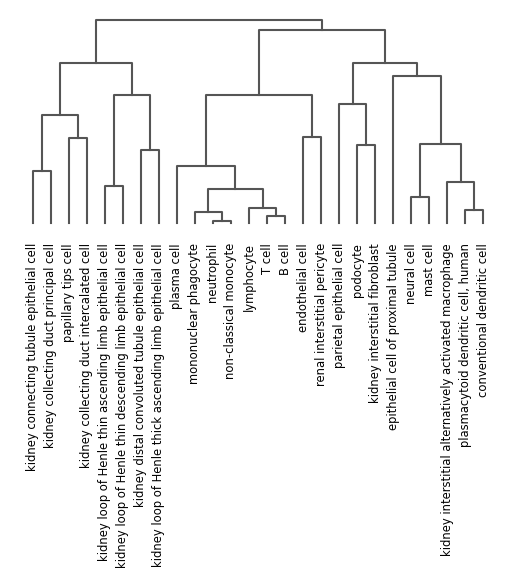

In [13]:
# full adata
if not adata.obsm or "X_pca" not in adata.obsm:
    sc.pp.pca(adata, random_state=seed)

ns.pp.dendrogram(adata, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)

Saving dendrogram as...
../beckersv_output_kidney/_cell_type.png


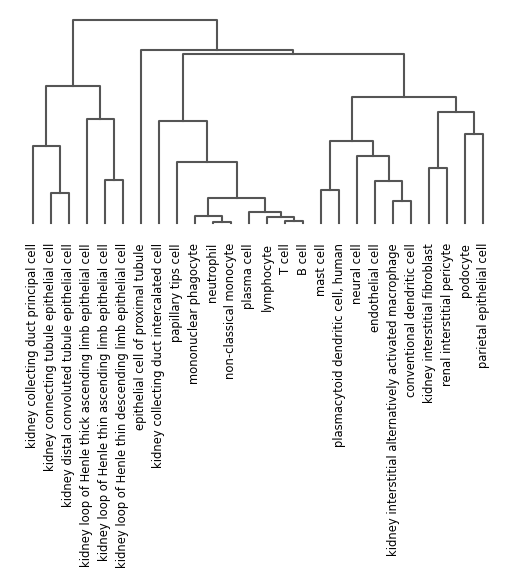

In [14]:
# subset adata
if not adata_subset.obsm or "X_pca" not in adata_subset.obsm:
    sc.pp.pca(adata_subset, random_state=seed)

ns.pp.dendrogram(adata_subset, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)

#### Calculating cluster medians per gene

Run `ns.pp.prep_medians` before running NS-Forest.

**Note:** Do **not** run if evaluating marker lists. Do **not** run when generating scanpy plots (e.g. dot plot, violin plot, matrix plot). 

In [15]:
# full adata
adata = ns.pp.prep_medians(adata, cluster_header)
adata.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 26/26 [00:21<00:00,  1.19it/s]


Saving medians as adata.varm.medians_cell_type
median: 0.0
mean: 0.012
std: 0.148
Only positive genes selected. 1933 positive genes out of 33140 total genes
--- 22.830470085144043 seconds ---


,B cell,T cell,conventional dendritic cell,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct intercalated cell,kidney collecting duct principal cell,kidney connecting tubule epithelial cell,kidney distal convoluted tubule epithelial cell,kidney interstitial alternatively activated macrophage,...,mononuclear phagocyte,neural cell,neutrophil,non-classical monocyte,papillary tips cell,parietal epithelial cell,plasma cell,"plasmacytoid dendritic cell, human",podocyte,renal interstitial pericyte
ENSG00000175899,0.0,0.0,0.0,1.413055,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.114692
ENSG00000115977,0.0,0.0,0.0,0.000000,0.0,0.000000,1.325979,0.843635,0.521632,0.0,...,0.0,0.0,0.0,0.0,0.588177,0.0,0.0,0.0,0.0,0.000000
ENSG00000198691,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
ENSG00000154265,0.0,0.0,0.0,0.000000,0.0,0.884318,0.000000,0.000000,1.148271,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
ENSG00000125257,0.0,0.0,0.0,0.000000,0.0,0.906396,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000


In [16]:
# subset adata
adata_subset = ns.pp.prep_medians(adata_subset, cluster_header)
adata_subset.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 26/26 [00:07<00:00,  3.30it/s]


Saving medians as adata.varm.medians_cell_type
median: 0.0
mean: 0.001
std: 0.068
Only positive genes selected. 45 positive genes out of 11509 total genes
--- 8.350650072097778 seconds ---


,B cell,T cell,conventional dendritic cell,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct intercalated cell,kidney collecting duct principal cell,kidney connecting tubule epithelial cell,kidney distal convoluted tubule epithelial cell,kidney interstitial alternatively activated macrophage,...,mononuclear phagocyte,neural cell,neutrophil,non-classical monocyte,papillary tips cell,parietal epithelial cell,plasma cell,"plasmacytoid dendritic cell, human",podocyte,renal interstitial pericyte
ENSG00000231312,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
ENSG00000236283,0.0,0.0,0.000000,0.0,0.0,1.491415,2.588741,2.960015,2.668397,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
ENSG00000225885,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.009196,0.000000,0.0
ENSG00000230027,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.635208,0.0
ENSG00000231873,0.0,0.0,1.654263,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


#### Calculating binary scores per gene per cluster

Run `ns.pp.prep_binary_scores` before running NS-Forest. Do not need to run if evaluating marker lists. Do not need to run when generating scanpy plots. 

In [17]:
# full adata
adata = ns.pp.prep_binary_scores(adata, cluster_header)
adata.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 26/26 [00:02<00:00, 12.20it/s]

Saving binary scores as adata.varm.binary_scores_cell_type
median: 0.0
mean: 0.108
std: 0.278
--- 2.141083002090454 seconds ---


,B cell,T cell,conventional dendritic cell,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct intercalated cell,kidney collecting duct principal cell,kidney connecting tubule epithelial cell,kidney distal convoluted tubule epithelial cell,kidney interstitial alternatively activated macrophage,...,mononuclear phagocyte,neural cell,neutrophil,non-classical monocyte,papillary tips cell,parietal epithelial cell,plasma cell,"plasmacytoid dendritic cell, human",podocyte,renal interstitial pericyte
ENSG00000175899,0.0,0.0,0.0,0.968446,0.0,0.000000,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.96
ENSG00000115977,0.0,0.0,0.0,0.000000,0.0,0.000000,0.907058,0.86738,0.840000,0.0,...,0.0,0.0,0.0,0.0,0.844526,0.0,0.0,0.0,0.0,0.00
ENSG00000198691,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00
ENSG00000154265,0.0,0.0,0.0,0.000000,0.0,0.960000,0.000000,0.00000,0.969195,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00
ENSG00000125257,0.0,0.0,0.0,0.000000,0.0,0.939698,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00


In [18]:
# subset adata
adata_subset = ns.pp.prep_binary_scores(adata_subset, cluster_header)
adata_subset.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 26/26 [00:00<00:00, 519.36it/s]

Saving binary scores as adata.varm.binary_scores_cell_type
median: 0.0
mean: 0.086
std: 0.254
--- 0.052052974700927734 seconds ---


,B cell,T cell,conventional dendritic cell,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct intercalated cell,kidney collecting duct principal cell,kidney connecting tubule epithelial cell,kidney distal convoluted tubule epithelial cell,kidney interstitial alternatively activated macrophage,...,mononuclear phagocyte,neural cell,neutrophil,non-classical monocyte,papillary tips cell,parietal epithelial cell,plasma cell,"plasmacytoid dendritic cell, human",podocyte,renal interstitial pericyte
ENSG00000231312,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000236283,0.0,0.0,0.0,0.0,0.0,0.803497,0.847739,0.865761,0.85109,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000225885,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ENSG00000230027,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ENSG00000231873,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Saving preprocessed AnnData as new h5ad

In [19]:
# full adata
filename = file.replace(".h5ad", "_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata.write_h5ad(filename)
adata

Saving new anndata object as...
../beckersv_data/nsf_kidney_preprocessed.h5ad


AnnData object with n_obs × n_vars = 100000 × 1933
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity

In [ ]:
# subset adata
filename = file.replace(".h5ad", f"_subset_{subset_gene}_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata_subset.write_h5ad(filename)
adata_subset

Saving new anndata object as...
../beckersv_data/nsf_kidney_subset_lncRNA_preprocessed.h5ad


AnnData object with n_obs × n_vars = 100000 × 45
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity',

### Running NS-Forest

**Note:** Do not run NS-Forest if only evaluating input marker lists. 

In [21]:
# full adata
outputfilename_prefix = cluster_header
results = ns.nsforesting.NSForest(adata, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
results

Running NS-Forest version 4.1

Preparing adata...
Pre-selecting genes based on binary scores...
	BinaryFirst_high Threshold (mean + 2 * std): 0.664
	Average number of genes after gene_selection in each cluster: 204.19230769230768
Saving number of genes selected per cluster as...
../beckersv_output_kidney/cell_type_gene_selection.csv
--- 0.16561388969421387 seconds ---

Number of clusters to evaluate: 26
1 out of 26:
	endothelial cell
	Pre-selected 78 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000127329', 'ENSG00000102755']
	fbeta: 0.831
	precision: 0.951
	recall: 0.552
2 out of 26:
	podocyte
	Pre-selected 437 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000151490', 'ENSG00000161270']
	fbeta: 0.904
	precision: 0.988
	recall: 0.675
3 out of 26:
	epithelial cell of proximal tubule
	Pre-selected 54 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000183747', 'ENSG00000066813']
	fbeta: 0.773
	precision: 0.884
	recall: 

Calculating medians per cluster: 100%|██████████| 26/26 [00:00<00:00, 48.87it/s]

Saving supplementary table as...
../beckersv_output_kidney/cell_type_markers_onTarget_supp.csv
Saving supplementary table as...
../beckersv_output_kidney/cell_type_markers_onTarget.csv

Saving final results table as...
../beckersv_output_kidney/cell_type_results.csv
Saving final results table as...
../beckersv_output_kidney/cell_type_results.pkl


,software_version,cluster_header,clusterName,clusterSize,f_score,precision,recall,TN,FP,FN,TP,marker_count,NSForest_markers,binary_genes,onTarget
0,4.1,cell_type,endothelial cell,8201,0.830918,0.950871,0.552250,91565,234,3672,4529,2,"[ENSG00000127329, ENSG00000102755]","[ENSG00000127329, ENSG00000172889, ENSG0000010...",1.000000
1,4.1,cell_type,podocyte,969,0.904064,0.987915,0.674923,99023,8,315,654,2,"[ENSG00000151490, ENSG00000161270]","[ENSG00000151490, ENSG00000153246, ENSG0000013...",1.000000
2,4.1,cell_type,epithelial cell of proximal tubule,25098,0.773253,0.883691,0.515539,73199,1703,12159,12939,2,"[ENSG00000183747, ENSG00000066813]","[ENSG00000183747, ENSG00000066813, ENSG0000016...",1.000000
3,4.1,cell_type,neural cell,24,0.781250,1.000000,0.416667,99976,0,14,10,1,[ENSG00000071991],"[ENSG00000179915, ENSG00000071991, ENSG0000013...",1.000000
4,4.1,cell_type,parietal epithelial cell,807,0.583296,0.736390,0.318463,99101,92,550,257,2,"[ENSG00000000971, ENSG00000168785]","[ENSG00000000971, ENSG00000128918, ENSG0000016...",1.000000
5,4.1,cell_type,papillary tips cell,184,0.556818,0.765625,0.266304,99801,15,135,49,3,"[ENSG00000173267, ENSG00000164266, ENSG0000011...","[ENSG00000176153, ENSG00000173267, ENSG0000016...",1.000000
6,4.1,cell_type,kidney interstitial fibroblast,5459,0.702850,0.950430,0.344202,94443,98,3580,1879,2,"[ENSG00000079931, ENSG00000107518]","[ENSG00000112936, ENSG00000079931, ENSG0000010...",1.000000
7,4.1,cell_type,kidney connecting tubule epithelial cell,4353,0.458538,0.547221,0.278199,94645,1002,3142,1211,3,"[ENSG00000104327, ENSG00000226674, ENSG0000016...","[ENSG00000104327, ENSG00000226674, ENSG0000013...",1.000000
8,4.1,cell_type,kidney distal convoluted tubule epithelial cell,4350,0.805067,0.838611,0.694023,95069,581,1331,3019,1,[ENSG00000070915],"[ENSG00000070915, ENSG00000146021, ENSG0000018...",1.000000
9,4.1,cell_type,kidney loop of Henle thick ascending limb epit...,21498,0.824621,0.872962,0.675086,76390,2112,6985,14513,1,[ENSG00000074803],"[ENSG00000074803, ENSG00000036828, ENSG0000016...",1.000000


In [22]:
# subset adata
outputfilename_prefix_subset = cluster_header + "_subset_" + subset_gene
results_subset = ns.nsforesting.NSForest(adata_subset, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)
results_subset

Running NS-Forest version 4.1

Preparing adata...
Pre-selecting genes based on binary scores...
	BinaryFirst_high Threshold (mean + 2 * std): 0.594
	Average number of genes after gene_selection in each cluster: 3.769230769230769
Saving number of genes selected per cluster as...
../beckersv_output_kidney/cell_type_subset_lncRNA_gene_selection.csv
--- 0.02142786979675293 seconds ---

Number of clusters to evaluate: 26
1 out of 26:
	endothelial cell
	Pre-selected 0 genes to feed into Random Forest.
2 out of 26:
	podocyte
	Pre-selected 14 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000230027']
	fbeta: 0.749
	precision: 0.785
	recall: 0.633
3 out of 26:
	epithelial cell of proximal tubule
	Pre-selected 3 genes to feed into Random Forest.
	Only 3 out of 15 top Random Forest features with median > 0 will be further evaluated.
	NSForest-selected markers: ['ENSG00000241158']
	fbeta: 0.519
	precision: 0.56
	recall: 0.402
4 out of 26:
	neural cell
	Pre-selected 7 genes t

Calculating medians per cluster: 100%|██████████| 26/26 [00:00<00:00, 45.62it/s]

Saving supplementary table as...
../beckersv_output_kidney/cell_type_subset_lncRNA_markers_onTarget_supp.csv
Saving supplementary table as...
../beckersv_output_kidney/cell_type_subset_lncRNA_markers_onTarget.csv

Saving final results table as...
../beckersv_output_kidney/cell_type_subset_lncRNA_results.csv
Saving final results table as...
../beckersv_output_kidney/cell_type_subset_lncRNA_results.pkl


,software_version,cluster_header,clusterName,clusterSize,f_score,precision,recall,TN,FP,FN,TP,marker_count,NSForest_markers,binary_genes,onTarget
0,4.1,cell_type,podocyte,969,0.748839,0.784891,0.632611,98863,168,356,613,1,[ENSG00000230027],"[ENSG00000230027, ENSG00000185904, ENSG0000024...",1.000000
1,4.1,cell_type,epithelial cell of proximal tubule,25098,0.519327,0.560035,0.402343,66969,7933,15000,10098,1,[ENSG00000241158],"[ENSG00000228262, ENSG00000241158, ENSG0000023...",0.268521
2,4.1,cell_type,neural cell,24,0.227273,0.400000,0.083333,99973,3,22,2,3,"[ENSG00000230490, ENSG00000231607, ENSG0000027...","[ENSG00000230490, ENSG00000229807, ENSG0000027...",0.369200
3,4.1,cell_type,papillary tips cell,184,0.015847,0.012831,0.266304,96046,3770,135,49,3,"[ENSG00000260032, ENSG00000229807, ENSG0000015...","[ENSG00000260032, ENSG00000229807, ENSG0000015...",0.331461
4,4.1,cell_type,kidney interstitial fibroblast,5459,0.493190,0.787591,0.197655,94250,291,4380,1079,2,"[ENSG00000237187, ENSG00000247809]","[ENSG00000237187, ENSG00000247809, ENSG0000027...",0.684487
5,4.1,cell_type,kidney connecting tubule epithelial cell,4353,0.414806,0.487102,0.260280,94454,1193,3220,1133,2,"[ENSG00000226674, ENSG00000236283]","[ENSG00000226674, ENSG00000229847, ENSG0000023...",0.614785
6,4.1,cell_type,kidney distal convoluted tubule epithelial cell,4350,0.318921,0.351511,0.232644,93783,1867,3338,1012,3,"[ENSG00000233154, ENSG00000236283, ENSG0000024...","[ENSG00000233154, ENSG00000235244, ENSG0000023...",0.206953
7,4.1,cell_type,kidney loop of Henle thick ascending limb epit...,21498,0.340277,0.311253,0.542702,52685,25817,9831,11667,1,[ENSG00000228262],"[ENSG00000228262, ENSG00000242086]",0.226170
8,4.1,cell_type,kidney loop of Henle thin ascending limb epith...,1117,0.331792,0.381250,0.218442,98487,396,873,244,3,"[ENSG00000258667, ENSG00000245694, ENSG0000027...","[ENSG00000258667, ENSG00000245694, ENSG0000023...",1.000000
9,4.1,cell_type,kidney loop of Henle thin descending limb epit...,3266,0.363614,0.397927,0.270361,95398,1336,2383,883,3,"[ENSG00000228262, ENSG00000272168, ENSG0000024...","[ENSG00000253438, ENSG00000228262, ENSG0000027...",0.477513


### Visualization (Preprocessing)

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output_kidney/histogram_medians_cell_type.png


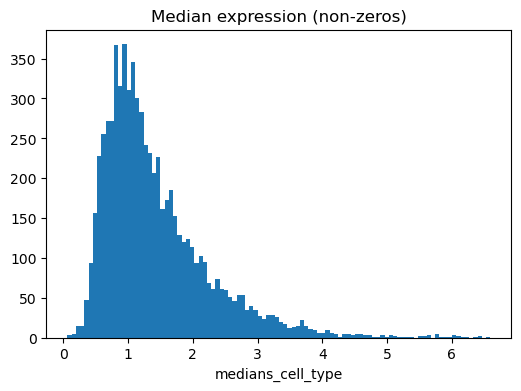

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output_kidney/histogram_medians_cell_type.png


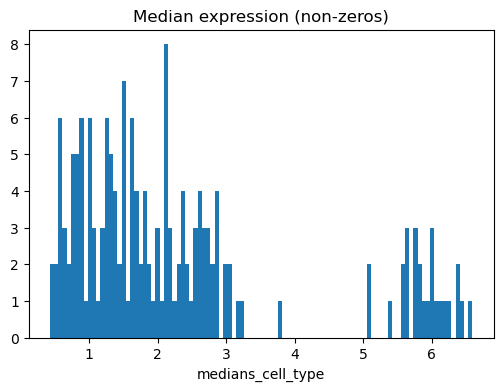

In [23]:
ns.pp.plot_varm(adata, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output_kidney/histogram_medians_cell_type.png


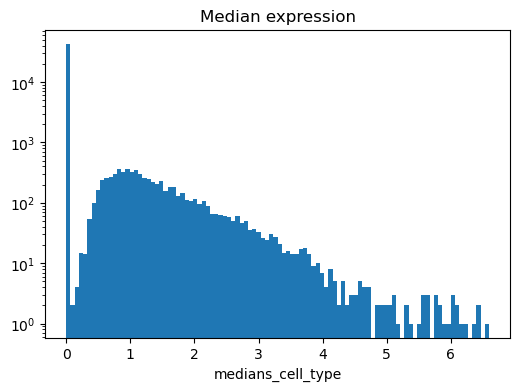

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output_kidney/histogram_medians_cell_type.png


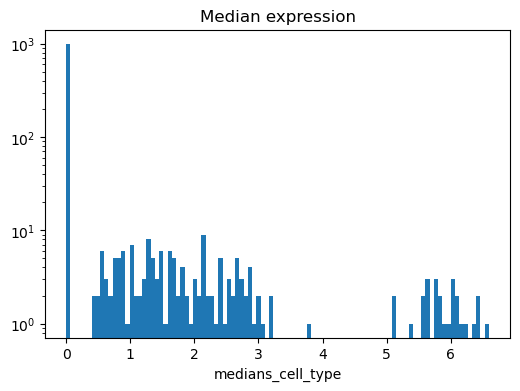

In [24]:
ns.pp.plot_varm(adata, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)

Saving adata.varm[binary_scores_cell_type] as histogram as...
../beckersv_output_kidney/histogram_binary_scores_cell_type.png


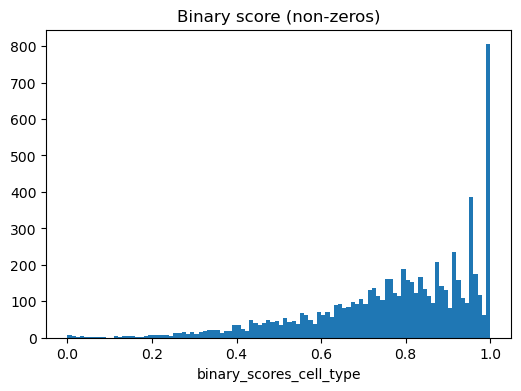

Saving adata.varm[binary_scores_cell_type] as histogram as...
../beckersv_output_kidney/histogram_binary_scores_cell_type.png


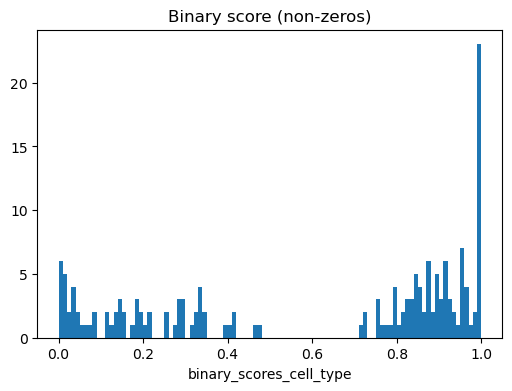

In [25]:
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)

Saving adata.varm[binary_scores_cell_type] as histogram as...
../beckersv_output_kidney/histogram_binary_scores_cell_type.png


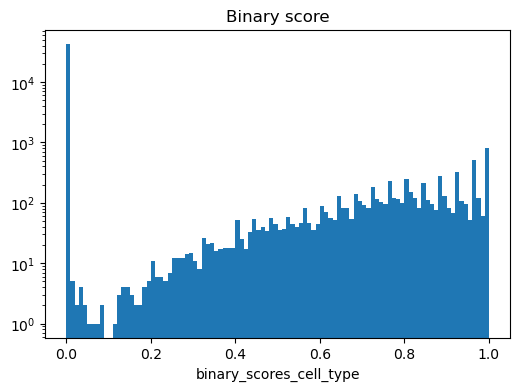

Saving adata.varm[binary_scores_cell_type] as histogram as...
../beckersv_output_kidney/histogram_binary_scores_cell_type.png


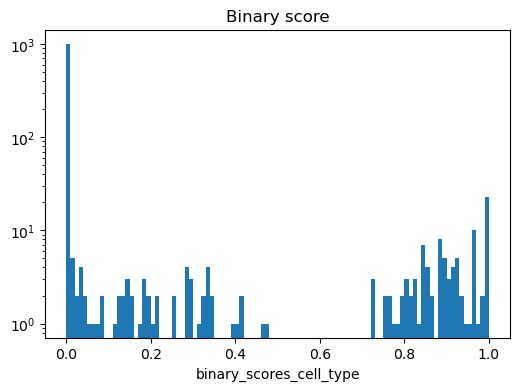

In [26]:
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)

### Visualization (Results): Plotting scanpy dot plot, violin plot, matrix plot for NS-Forest markers

**Note:** Assign pre-defined dendrogram order here **or** use `adata.uns["dendrogram_" + cluster_header]["categories_ordered"]`. 

In [27]:
to_plot = results.copy()
to_plot_subset = results_subset.copy()

In [28]:
# full adata
dendrogram = [] # custom dendrogram order
dendrogram = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot["clusterName"] = to_plot["clusterName"].astype("category")
to_plot["clusterName"] = to_plot["clusterName"].cat.set_categories(dendrogram)
to_plot = to_plot.sort_values("clusterName")
to_plot = to_plot.rename(columns = {"NSForest_markers": "markers"})

In [29]:
# subset adata
dendrogram_subset = [] # custom dendrogram order
dendrogram_subset = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].astype("category")
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].cat.set_categories(dendrogram_subset)
to_plot_subset = to_plot_subset.sort_values("clusterName")
to_plot_subset = to_plot_subset.rename(columns = {"NSForest_markers": "markers"})

In [30]:
# full adata
markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))
markers_dict

{'kidney connecting tubule epithelial cell': ['ENSG00000104327',
  'ENSG00000226674',
  'ENSG00000165685'],
 'kidney collecting duct principal cell': ['ENSG00000150201',
  'ENSG00000112319',
  'ENSG00000138696'],
 'papillary tips cell': ['ENSG00000173267',
  'ENSG00000164266',
  'ENSG00000112378'],
 'kidney collecting duct intercalated cell': ['ENSG00000147614',
  'ENSG00000249601'],
 'kidney loop of Henle thin ascending limb epithelial cell': ['ENSG00000140600',
  'ENSG00000178538'],
 'kidney loop of Henle thin descending limb epithelial cell': ['ENSG00000007062',
  'ENSG00000165443'],
 'kidney distal convoluted tubule epithelial cell': ['ENSG00000070915'],
 'kidney loop of Henle thick ascending limb epithelial cell': ['ENSG00000074803'],
 'plasma cell': ['ENSG00000170476'],
 'mononuclear phagocyte': ['ENSG00000231389', 'ENSG00000223865'],
 'neutrophil': ['ENSG00000143546', 'ENSG00000163220'],
 'non-classical monocyte': ['ENSG00000203747', 'ENSG00000204482'],
 'lymphocyte': ['ENSG0000

In [31]:
# subset adata
markers_dict_subset = dict(zip(to_plot_subset["clusterName"], to_plot_subset["markers"]))
markers_dict_subset

{'kidney connecting tubule epithelial cell': ['ENSG00000226674',
  'ENSG00000236283'],
 'kidney collecting duct principal cell': ['ENSG00000229847',
  'ENSG00000236283'],
 'papillary tips cell': ['ENSG00000260032',
  'ENSG00000229807',
  'ENSG00000153113'],
 'kidney collecting duct intercalated cell': ['ENSG00000249601'],
 'kidney loop of Henle thin ascending limb epithelial cell': ['ENSG00000258667',
  'ENSG00000245694',
  'ENSG00000274265'],
 'kidney loop of Henle thin descending limb epithelial cell': ['ENSG00000228262',
  'ENSG00000272168',
  'ENSG00000241158'],
 'kidney distal convoluted tubule epithelial cell': ['ENSG00000233154',
  'ENSG00000236283',
  'ENSG00000241684'],
 'kidney loop of Henle thick ascending limb epithelial cell': ['ENSG00000228262'],
 'non-classical monocyte': ['ENSG00000177410'],
 'renal interstitial pericyte': ['ENSG00000249669'],
 'podocyte': ['ENSG00000230027'],
 'kidney interstitial fibroblast': ['ENSG00000237187', 'ENSG00000247809'],
 'epithelial cell o

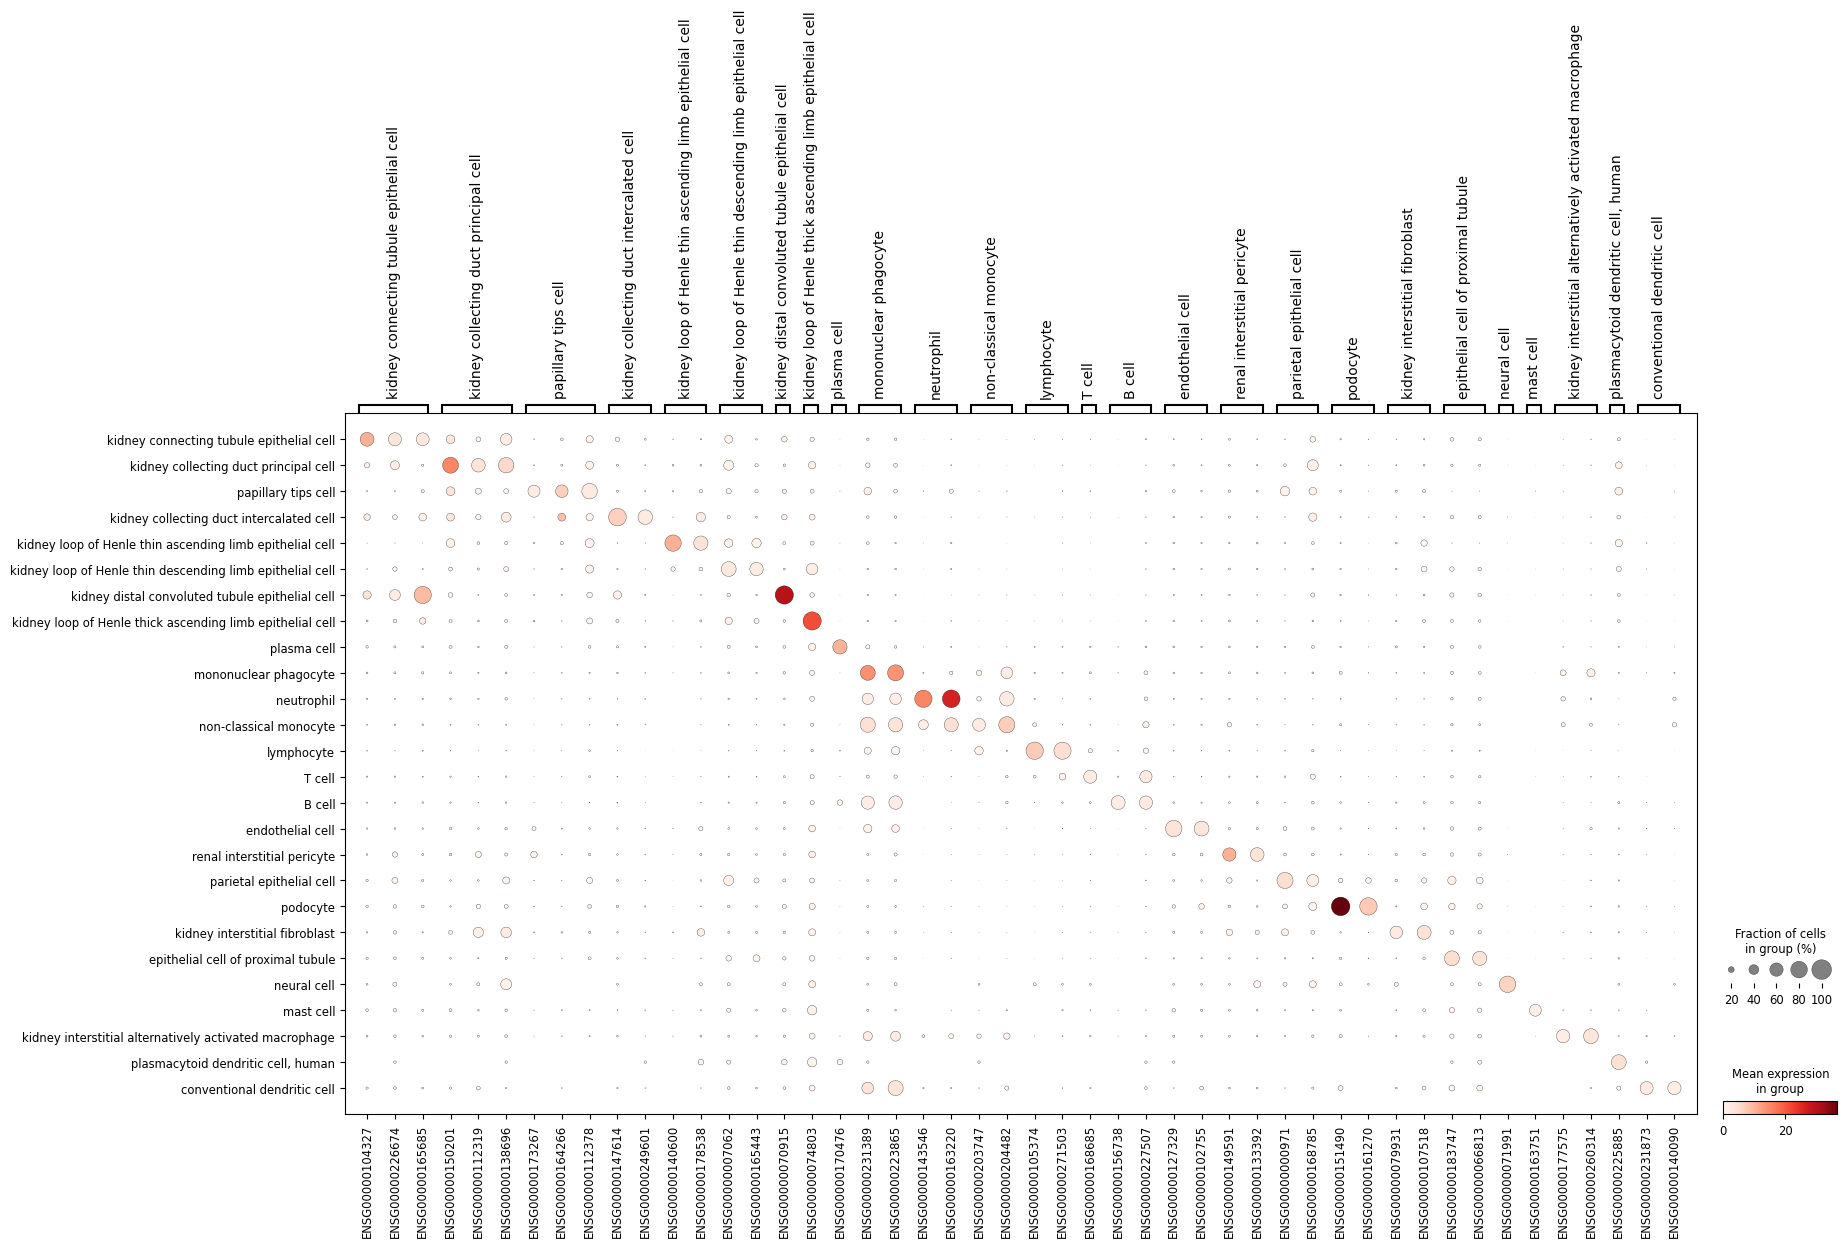

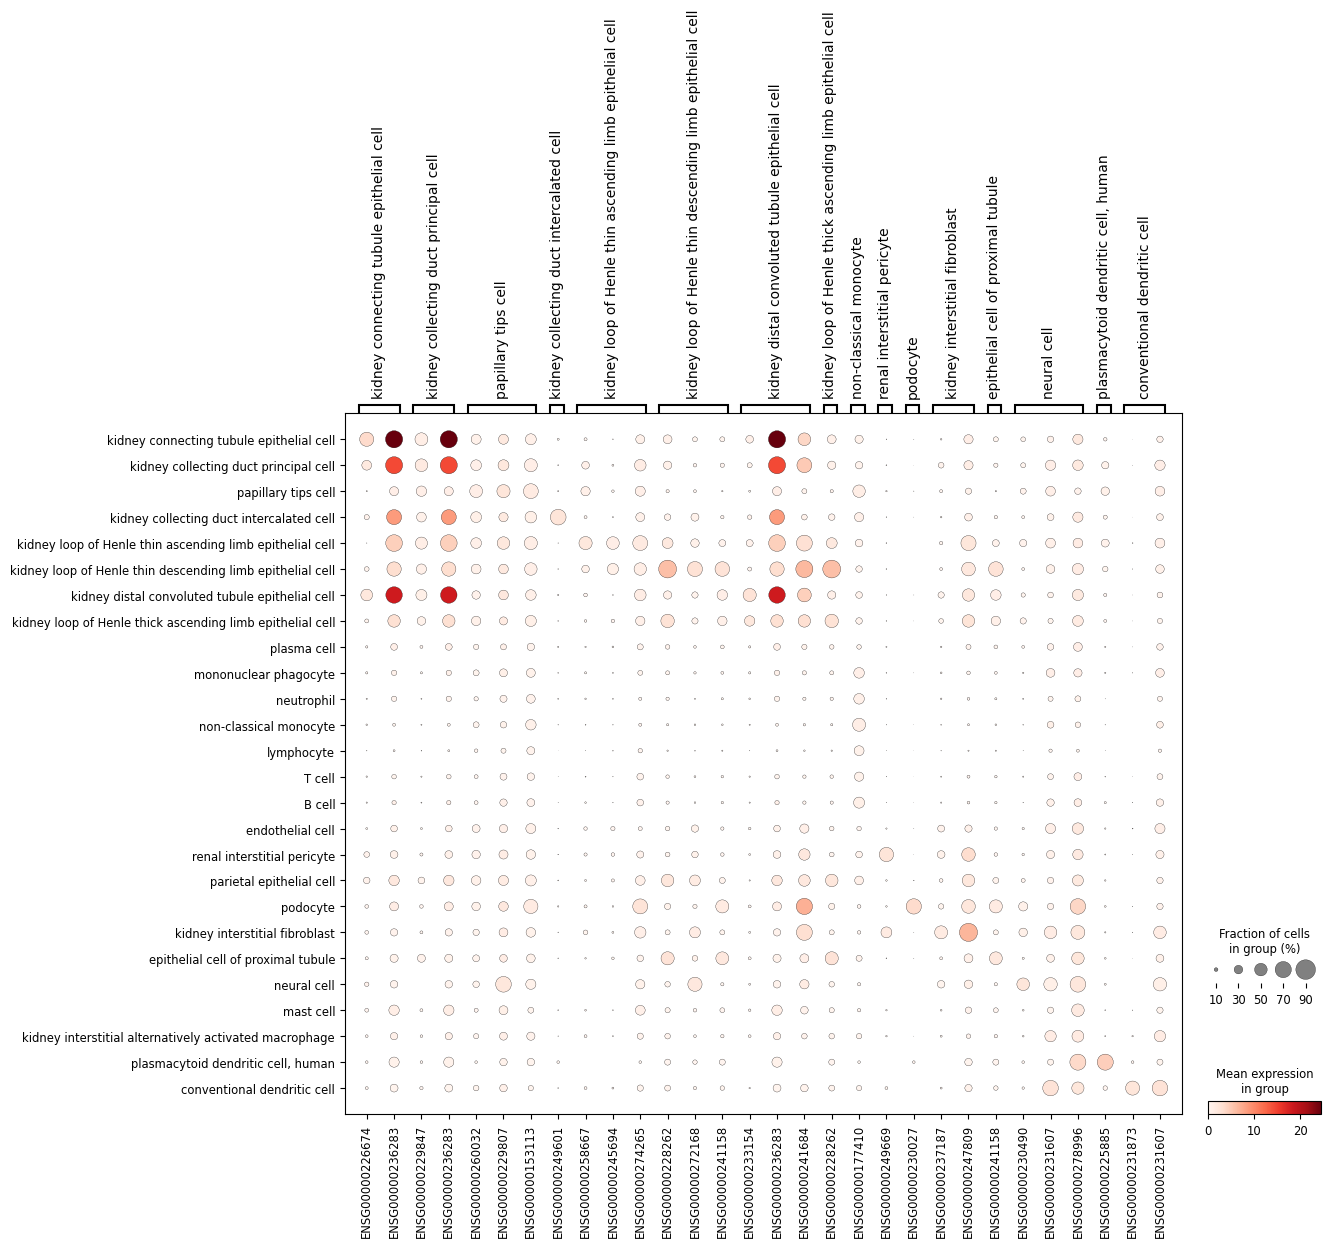

In [32]:
ns.pl.dotplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.dotplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

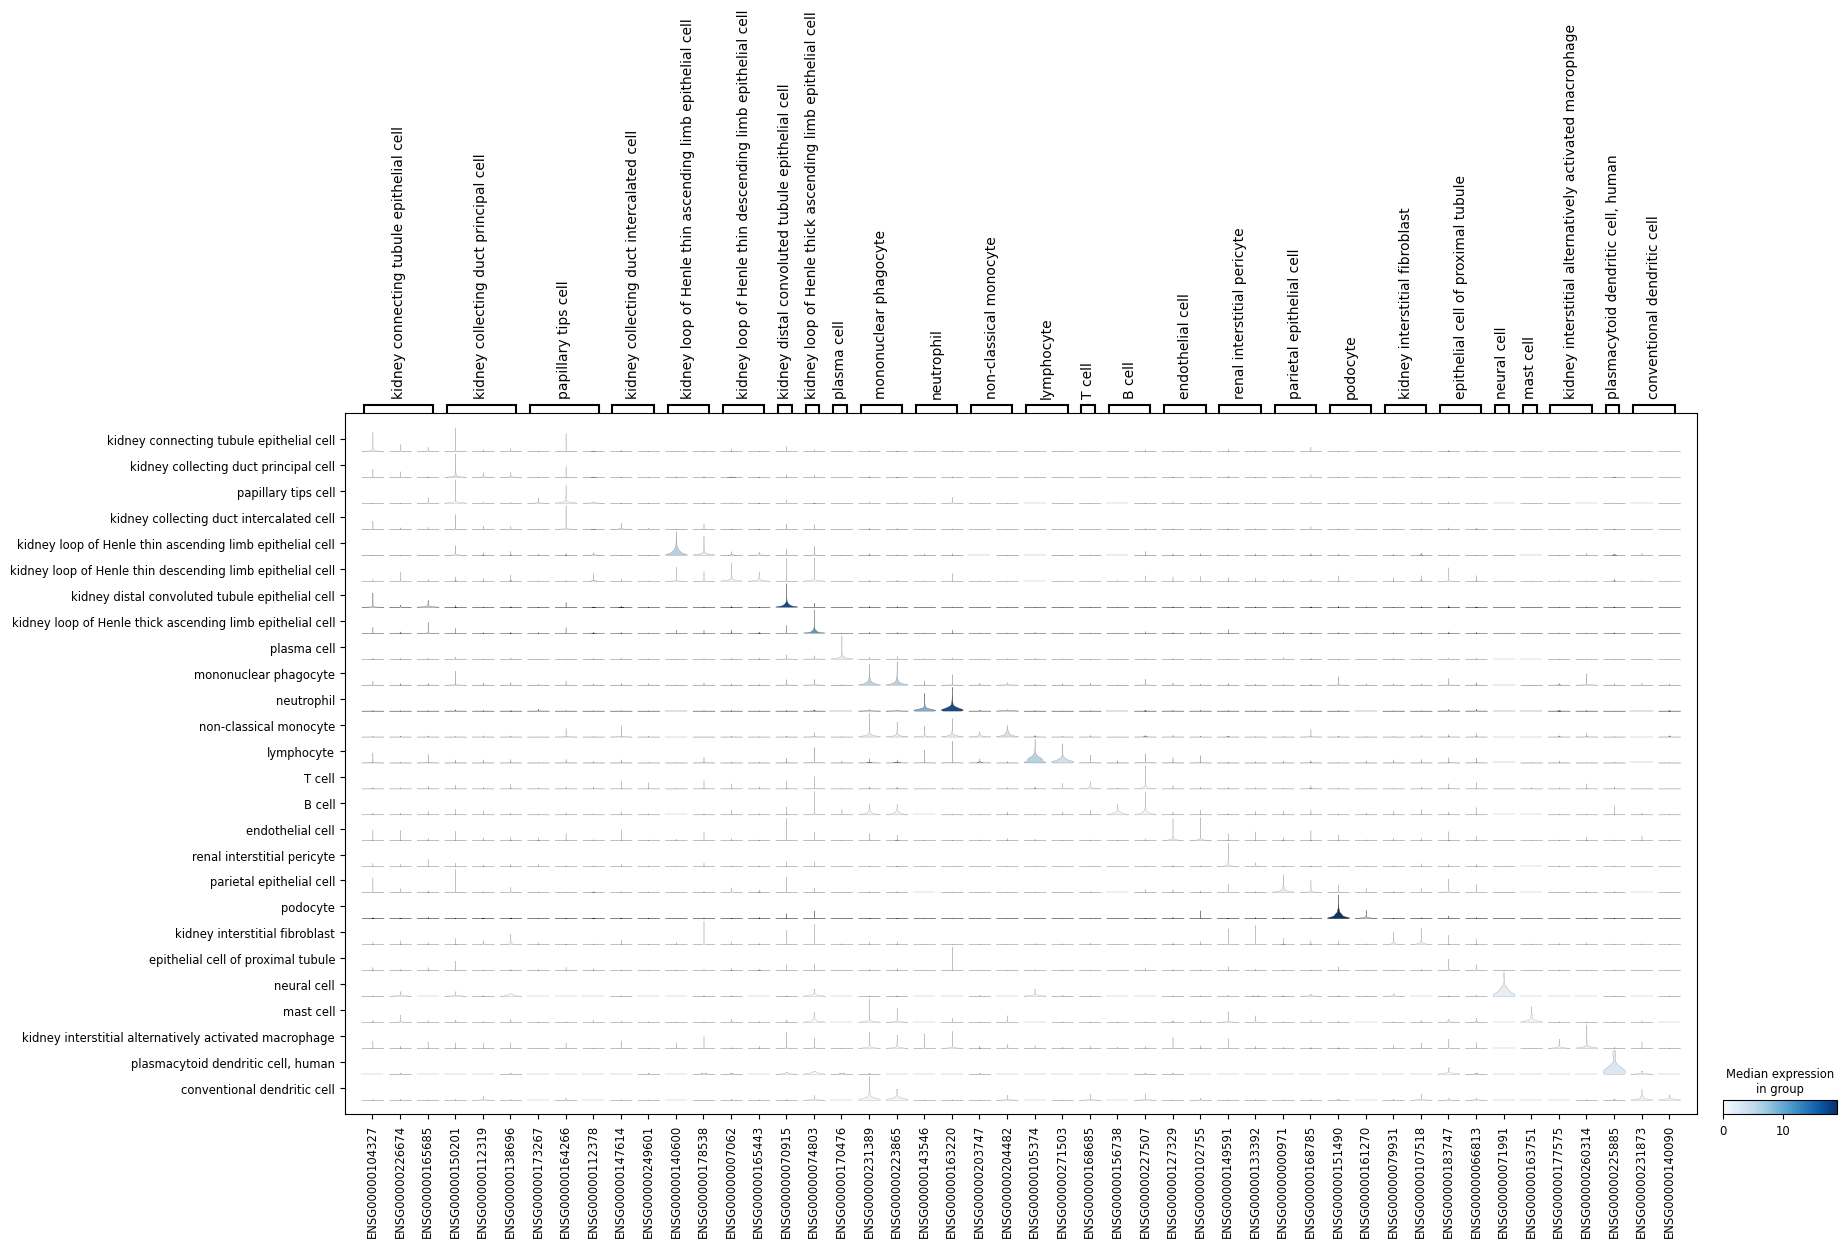

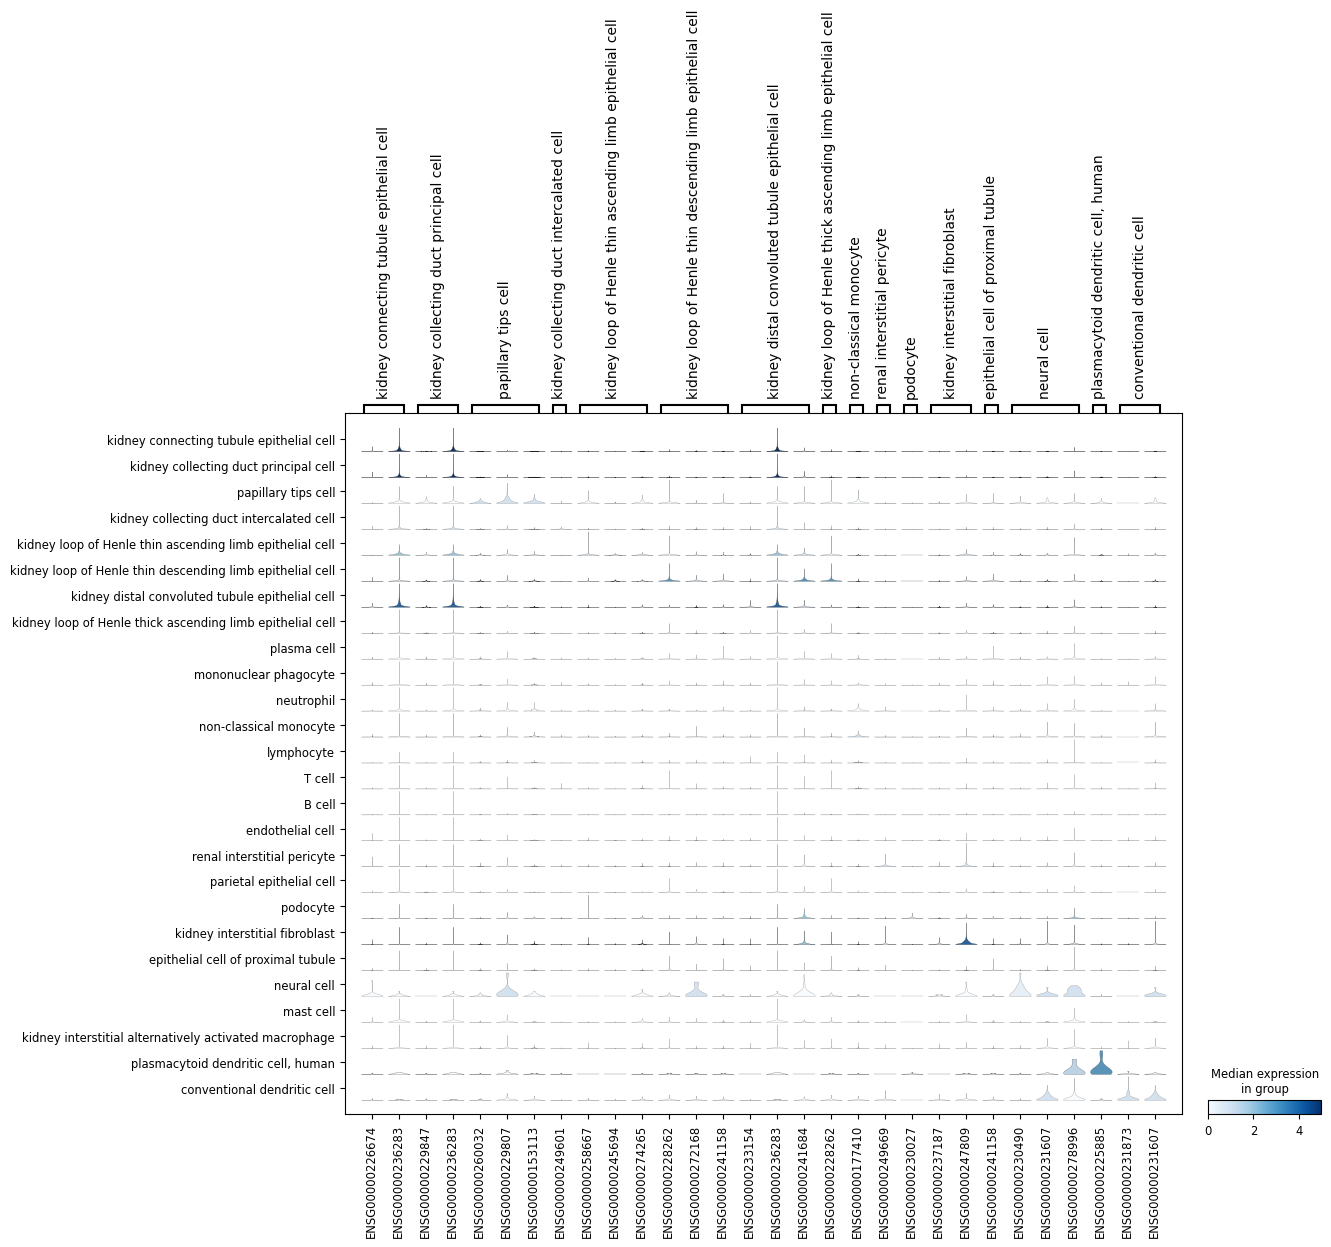

In [33]:
ns.pl.stackedviolin(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.stackedviolin(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

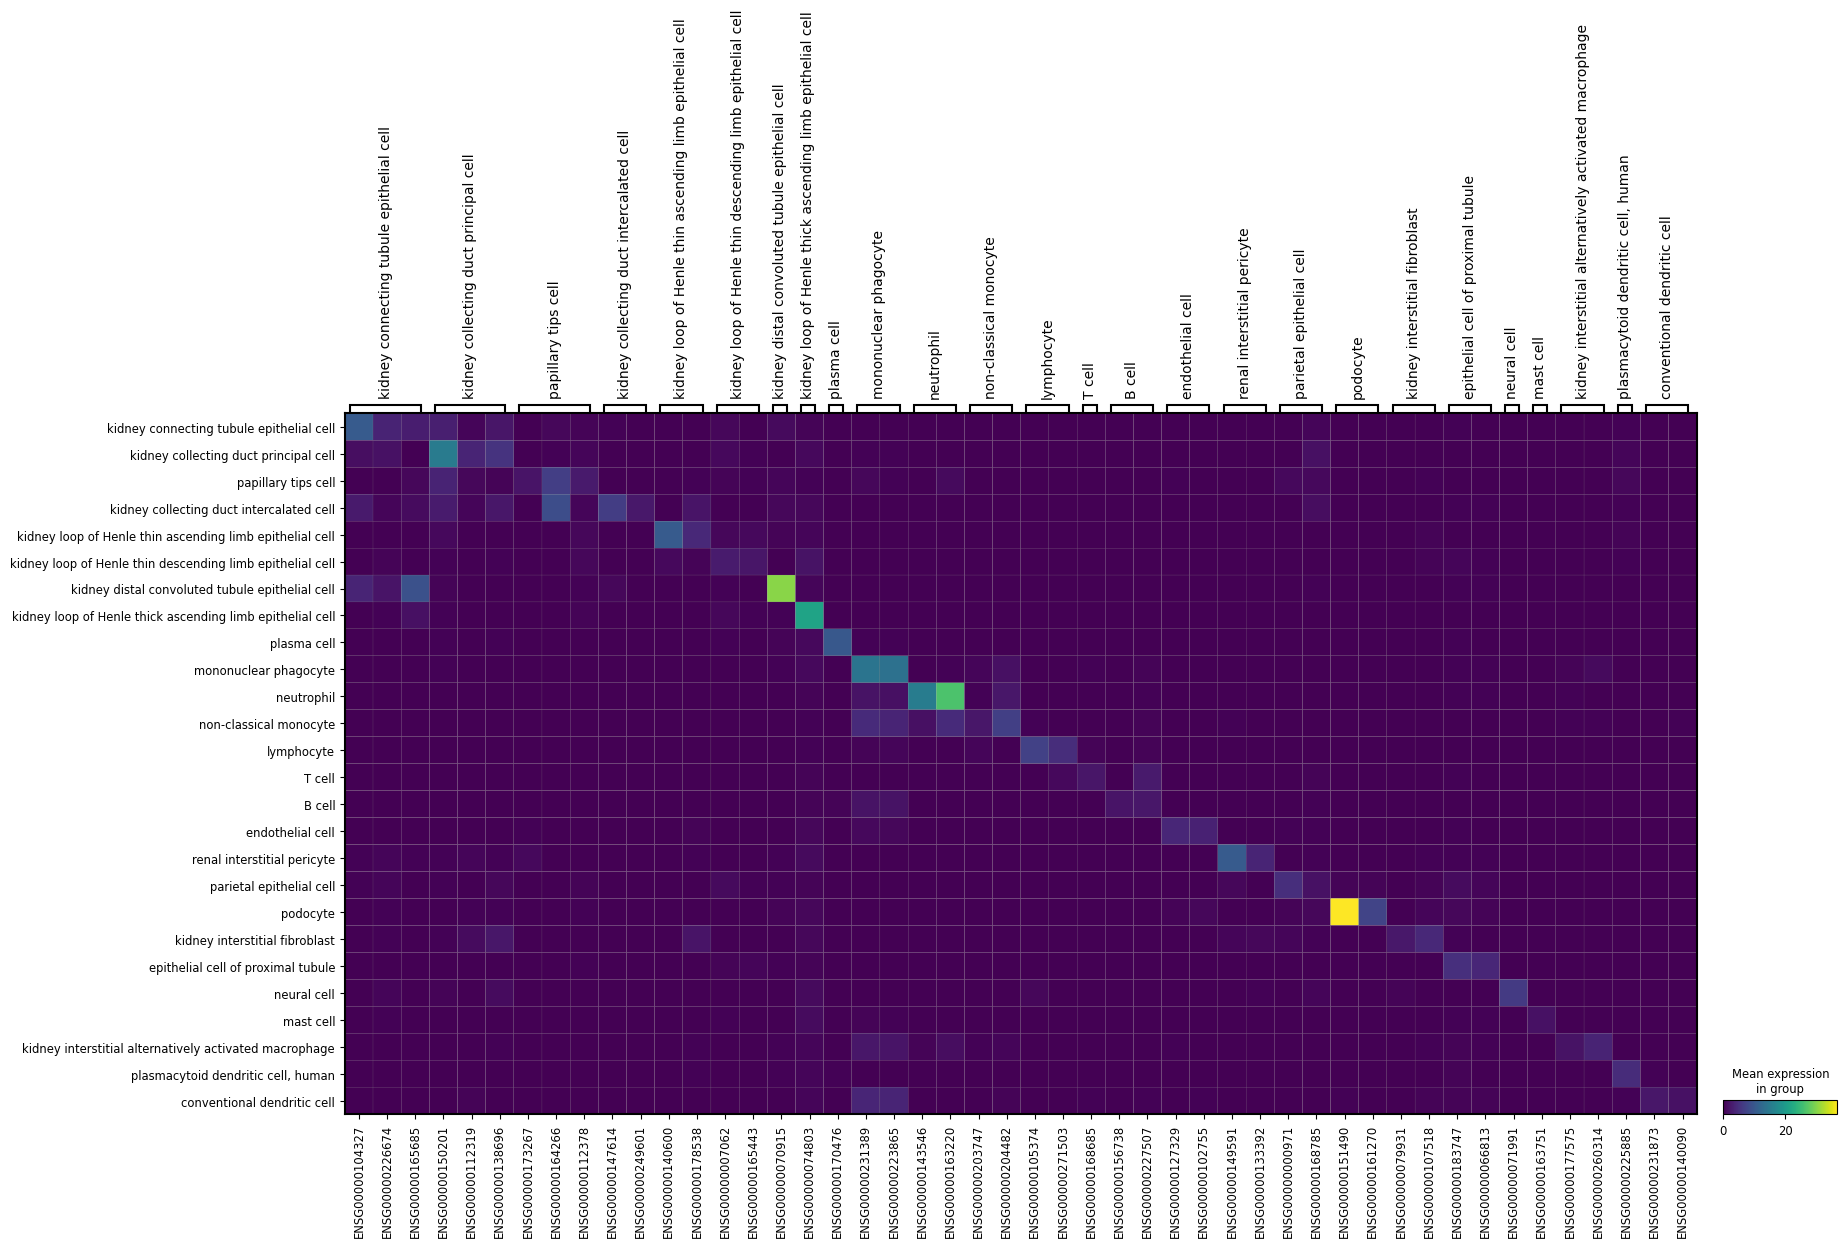

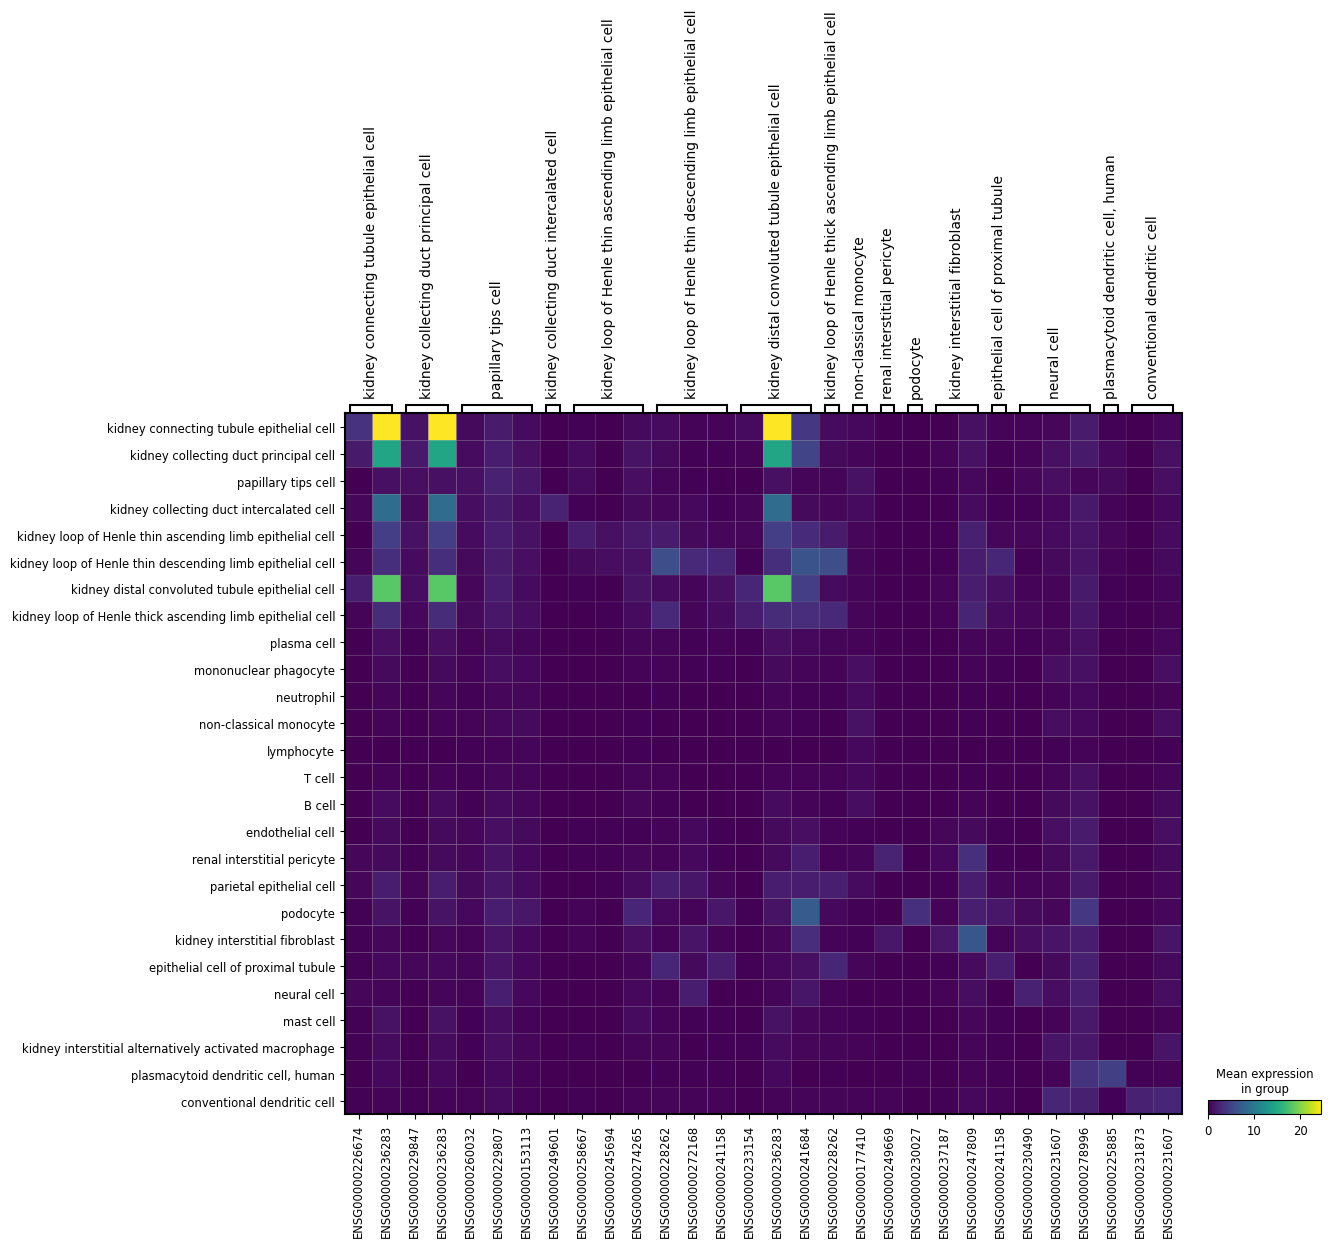

In [34]:
ns.pl.matrixplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.matrixplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

#### Plotting classification metrics from NS-Forest results

In [35]:
ns.pl.boxplot(results, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.boxplot(results_subset, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_kidney/cell_type_boxplot_f_score_precision_recall_onTarget.html
Saving...
 ../beckersv_output_kidney/cell_type_subset_lncRNA_boxplot_f_score_precision_recall_onTarget.html


#### Plotting individual classification metrics

In [36]:
ns.pl.boxplot(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.boxplot(results_subset, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_kidney/cell_type_boxplot_f_score.html
Saving...
 ../beckersv_output_kidney/cell_type_subset_lncRNA_boxplot_f_score.html


#### Plotting metrics vs clusterSize

In [37]:
ns.pl.scatter_w_clusterSize(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_kidney/cell_type_scatter_f_score.html
Saving...
 ../beckersv_output_kidney/cell_type_subset_lncRNA_scatter_f_score.html


In [38]:
ns.pl.scatter_w_clusterSize(results, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_kidney/cell_type_scatter_precision.html
Saving...
 ../beckersv_output_kidney/cell_type_subset_lncRNA_scatter_precision.html


In [39]:
ns.pl.scatter_w_clusterSize(results, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_kidney/cell_type_scatter_recall.html
Saving...
 ../beckersv_output_kidney/cell_type_subset_lncRNA_scatter_recall.html


In [40]:
ns.pl.scatter_w_clusterSize(results, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_kidney/cell_type_scatter_onTarget.html
Saving...
 ../beckersv_output_kidney/cell_type_subset_lncRNA_scatter_onTarget.html
